[![logo](https://climate.copernicus.eu/sites/default/files/custom-uploads/branding/LogoLine_horizon_C3S.png)](https://climate.copernicus.eu)

# EDD Energy demand proxy

The European energy sector is highly dependent on climate conditions, as weather variability significantly impacts electricity demand and renewable energy generation. Understanding these effects is crucial for energy system planning, market operations, and climate resilience. Energy Degree Days (EDD) can be used as proxy for energy demand variations in place of more advanced statistical methods specifically for countries where electricity load data are unavailable or have inadequate quality. 

## Learning objectives 🎯

Throughout this notebook, you will:
* understand the concept of Energy Degree Days (EDD) and its role as a proxy for energy demand;
* learn how to compute Heating Degree Days (HDD) and Cooling Degree Days (CDD) using standardized methodologies (HDDThold18 and CDDThold21);
* gain experience working with ERA5 reanalysis temperature data;
* apply conditional logic in temperature-based energy calculations;
* learn how to calculate climatological monthly averages;
* understand how to validate climate-derived indicators against established datasets (e.g., IEA).

## Target Audience 🎯

**Anyone** interested in learning how to estimate energy demand using temperature data and energy degree days proxy.

## EDD definition

For all countries, including those in Europe, the electricity demand – or more precisely energy demand – is represented by a proxy, Energy Degree Days (EDD). EDD can be used as proxy for energy demand variations in place of more advanced statistical methods specifically for countries where electricity load data are unavailable or have inadequate quality.

**EDD is defined as the sum of Heating Degree Days (HDD) and Cooling Degree Days (CDD)**, both of which are computed according to standard methodologies, also recently adopted by the International Energy Agency (IEA). 

HDD is a climate indicator used in the estimation of the needs and demand of energy for heating purposes. There are several operational definitions for HDD. In the case of the current C3S Energy Lot1 service, HDD is defined as the monthly sum of the daily difference between a reference temperature (perceived as comfortable) and the daily average of the outside air temperature (at 2 m height, $T_{2m}$) but only when T2M subceeds a threshold temperature (a condition that defines the “heating days” throughout the year), according to the following definition (all temperatures in °C): 

$$  HDD = \begin{cases}
        T_{ref} – T_{2m} & T_{2m} \leq T_{threshold}\\
        0 & T_{2m} \gt T_{threshold} \\
    \end{cases}
$$ 

More specifically, the HDD definition of HHDThold18 (IEA, 2023; Scoccimarro et al., 2023) has been used, with reference temperature 18°C and threshold temperature 15°C. As an example, this means that if the daily mean air temperature is 12°C, for that day the value of the HDD is 6 (18°C-12°C), whereas if the daily mean air temperature is 16°C, for that day the HDD is 0.  

Similarly to HDD, CDD is a climate indicator used in the estimation of the needs and demand of energy for cooling purposes. CDD is here defined as the monthly sum of the daily difference between a reference temperature (perceived as comfortable) and the daily average of the outside air temperature (at 2 m height, T2M) but only when T2M exceeds a threshold temperature (a condition that defines the “cooling days” throughout the year), according to the following definition (all temperatures in °C): 

$$  CDD = \begin{cases}
        T_{2m} – T_{ref} & T_{2m} \geq T_{threshold} \\
        0 & T_{2m} \lt T_{threshold} \\
    \end{cases}
$$ 

The CDD definition of CDDThold21 (IEA, 2023; Scoccimarro et al., 2023) has been used, with reference temperature 21°C and threshold temperature 24°C. As an example, this means that if the daily mean air temperature is 26°C, for that day the value of the CDD is 5 (26°C-21°C). If the daily mean air temperature is 22°C, for that day the CDD is 0. 

## Prepare your environment

### Import required packages

We start by importing some useful libraries. These include: [os](https://docs.python.org/3/library/os.html), which provides a way to interact with the operating system and it is used here to manipulate paths; [pandas](https://pandas.pydata.org/), one of the most common and easy to use tools for data analysis and manipulation; [numpy](https://numpy.org/doc/stable/), fundamental for numerical computing; [matplotlib](https://matplotlib.org/), a standard library for creating visualizations in Python; [xarray](https://docs.xarray.dev/en/stable/index.html), a library to work with multidimensional arrays in NetCDF format.

In [1]:
# importing libraries
import os
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import dask

## Load the data

Now we will load ERA5 temperature at 2 meters data for the month of June and November (as examples) of a specified year (2015) into a Xarray datarray, first by collecting all the file paths sorted by name and then using xarray method open_mfdataset.

In [2]:
# define year
year = 2015
# define directory containing ERA5 .nc files
base_dir = "./data/nc/ta/"
# collect file paths and sort them
file_paths = sorted(glob.glob(os.path.join(base_dir, f"*S{year}*.nc")))
#print(file_paths)
ds_t2m = xr.open_mfdataset(file_paths, chunks={'time': 12})
ds_t2m

<xarray.Dataset> Size: 12GB
Dimensions:    (time: 1440, latitude: 721, longitude: 1440)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 12kB 2015-06-01 ... 2015-11-30T23:00:00
Data variables:
    t2m        (time, latitude, longitude) float64 12GB dask.array<chunksize=(12, 721, 1440), meta=np.ndarray>
Attributes:
    title:        2 metre temperature
    institution:  Copernicus Climate Change Service, Sectoral Information Sys...
    source:       ERA5 reanalysis data provided by ECMWF (https://www.ecmwf.i...
    history:      2024-09-26 14:06:30 GMT by write_hist_xr_to_nc-0.1.dev51+g1...
    references:   
    Conventions:  CF-1.12-draft

In order to compute CDD and HDD, we need to define reference temperature $T_{ref}$ and threshold temperature $T_{threshold}$.

In [3]:
# define reference and threshold temperature for CDD in degree Celsius
T_CDD = {'ref' : 21, 'thresh' : 24} 
# define reference and threshold temperature for HDD in degree Celsius
T_HDD = {'ref' : 18, 'thresh' : 15} 

Next we are going to implement the function to compute EDD, using the previous reference and threshold temperature. We will make use of xr.where method

In [4]:
# define function to compute CDD
def compute_CDD(t2m, Tref, Tthresh):
    return xr.where(t2m<Tthresh, 0, t2m-Tref)#.resample(time='1ME').sum()
    #return ((t2m - Tref).clip(min=0)) * (t2m > Tthresh)
# define function to compute HDD
def compute_HDD(t2m, Tref, Tthresh):
    return xr.where(t2m<Tthresh, Tref-t2m, 0)#.resample(time='1ME').sum()
    #return ((Tref - t2m).clip(min=0)) * (t2m < Tthresh)

Now we will define the latitude longitude of a location of interest and compute the CDD and HDD daily values for a given month, as a check that our code is working as intended.
In order to do that we need first to compute the daily average of temperature, in order to do that we will use the resample method of xarray, then call our previously defined functions, and finally call the compute method.

In [5]:
# define latitude and longitude
lat, lon = 40.25, 18.25 # southern Italy
# convert from K to degrees Celsius
t2m_loc = ds_t2m.t2m.sel(latitude=lat, longitude=lon, method='nearest') - 273.16
# select temperature for the month
#t2m_loc = t2m_loc.sel(time=t2m_loc.time.dt.month==month)
# resample from hourly resolution to daily average
t2m_loc = t2m_loc.resample(time='1D').mean()
# compute CDD and HDD
cdd = compute_CDD(t2m_loc, T_CDD['ref'], T_CDD['thresh']).compute()
hdd = compute_HDD(t2m_loc, T_HDD['ref'], T_HDD['thresh']).compute()

In [6]:
print(cdd)

<xarray.DataArray 't2m' (time: 183)> Size: 1kB
array([0.        , 0.        , 0.        , 3.66548518, 4.20959243,
       4.22588976, 3.16082659, 0.        , 0.        , 0.        ,
       3.96168017, 4.86234852, 5.37076412, 4.75446124, 5.56541815,
       4.68130098, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 3.0177046 , 0.        ,
       0.        , 3.15148482, 0.        , 3.6950336 , 3.23830234,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              n

In [7]:
print(hdd)

<xarray.DataArray 't2m' (time: 183)> Size: 1kB
array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.      

Now we are going to plot CDD and HDD previously computed together with temperature dataset, threshold temperatures and reference temperature. We will select a specific month and look at the daily values, in order to see if our computation is correct:

12.382052898406982


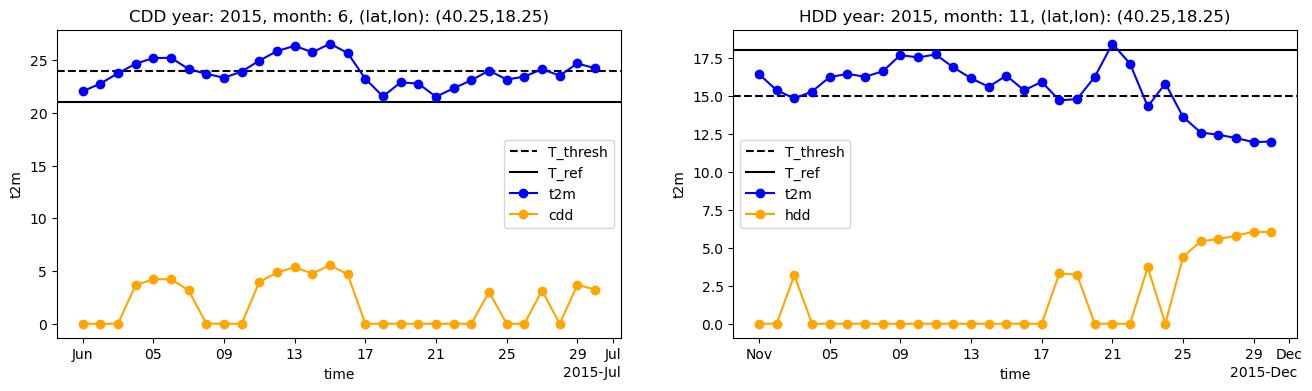

In [19]:
start=time.time()
# CDD plot
cdd_month = 6
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))
# plot temperature threshold horizontal dotted lines
ax1.axhline(y=T_CDD['thresh'], color='black', linestyle='--', label='T_thresh')
ax1.axhline(y=T_CDD['ref'], color='black', linestyle='-', label='T_ref')
# plot temperature
t2m_loc.sel(time=t2m_loc.time.dt.month==cdd_month).plot(ax=ax1, color='blue', marker='o', label='t2m')
# plot CDD and HDD on secondary y-axis
cdd.sel(time=cdd.time.dt.month==cdd_month).plot(ax=ax1, color='orange', marker='o', label='cdd')
ax1.legend()
ax1.set_title(f"CDD year: {year}, month: {cdd_month}, (lat,lon): ({lat},{lon})")

# HDD plot
hdd_month = 11
ax2.axhline(y=T_HDD['thresh'], color='black', linestyle='--', label='T_thresh')
ax2.axhline(y=T_HDD['ref'], color='black', linestyle='-', label='T_ref')
# plot temperature
t2m_loc.sel(time=t2m_loc.time.dt.month==hdd_month).plot(ax=ax2, color='blue', marker='o', label='t2m')
hdd.sel(time=cdd.time.dt.month==hdd_month).plot(ax=ax2, color='orange', marker='o', label='hdd')
ax2.legend()
# plo
ax2.set_title(f"HDD year: {year}, month: {hdd_month}, (lat,lon): ({lat},{lon})")
#plt.legend()
print(time.time()-start)

Indeed we can see that only when t2m is higher than the threshold temperature the cdd value is greater than zero, and equal to the difference between daily maen temperature and reference temperature; the same happens for hdd. Now we are going to sum daily values in order to compute monthly cdd and hdd, then sum them to compute edd, and plot the resulting time series. Since we are considering only the months of June and November, the plot will show data only for June and November.

Text(0.5, 1.0, 'EDD year: 2015, (lat,lon): (40.25,18.25)')

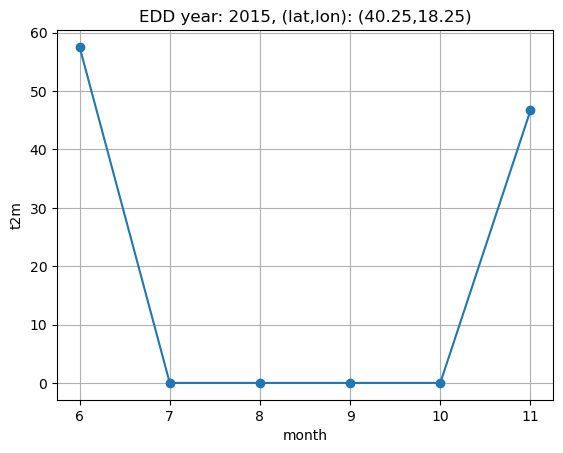

In [9]:
#fig, ax1 = plt.subplots(figsize=(12,6))
edd = (cdd + hdd).groupby('time.month').sum()
edd.plot(marker='o')
plt.grid()
plt.title(f"EDD year: {year}, (lat,lon): ({lat},{lon})")

## Aggregated EDD per country

In this section we are going to compute edd values for a selected country. In order to do that we need to load a netcdf mask of ADM0 countries; this will allow us to compute the EDD value by aggregating the values of all latitudes and longitudes points of that country. We will do this for a given month.

In [10]:
# path to ADM0 mask netcdf
adm0_path = "./data/nc/agg_mask/ANCI_ADM0B-mask_C3S2LOT1_025d_v1.00.nc"
adm0_mask = xr.open_dataset(adm0_path).mask
adm0_mask

<xarray.DataArray 'mask' (region: 242, latitude: 721, longitude: 1440)> Size: 2GB
[251254080 values with dtype=float64]
Coordinates:
  * region     (region) <U4 4kB 'GB' 'TZ' 'RS' 'PT' 'PG' ... 'DZ' 'AL' 'AF' 'SX'
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8

We are going to compute edd aggregated value for France. But before doing that, we define a helper function in order to translate longitude values from [0, 360] to [-180, 180]:

In [11]:
def shift_longitude(ds):
    ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180))
    return ds.sortby('longitude')

In [12]:
adm0_mask = shift_longitude(adm0_mask)
adm0_mask

<xarray.DataArray 'mask' (region: 242, latitude: 721, longitude: 1440)> Size: 2GB
[251254080 values with dtype=float64]
Coordinates:
  * region     (region) <U4 4kB 'GB' 'TZ' 'RS' 'PT' 'PG' ... 'DZ' 'AL' 'AF' 'SX'
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8

As one can see the mask dataarray contains float64 values and has a coordinate called 'region' that corresponds to ADM0 countries definitions. The mask is float because it considers the fraction of a pixel contained in a given region. We are going to select one of those region and plot the datarray:

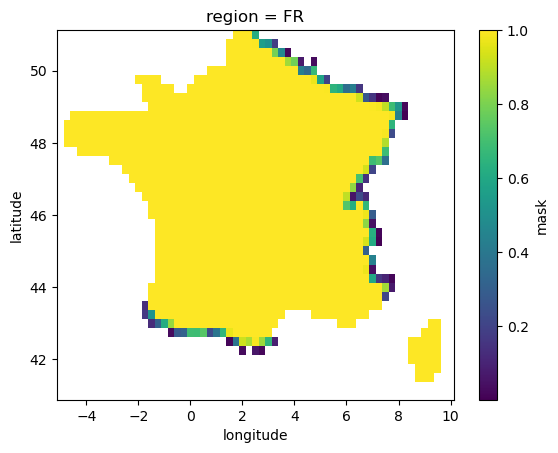

In [13]:
selected_region = 'FR'
lat_slice, lon_slice = slice(47, 45), slice(13, 17)
lat_slice, lon_slice = slice(51, 41), slice(-5, 10)
region_mask = adm0_mask.sel(region=selected_region)
# replace 0 with np.nan
region_mask = xr.where(region_mask>0, region_mask, np.nan).sel(latitude=lat_slice,longitude=lon_slice).compute()
region_mask.plot()

Now we are going to compute EDD for each of the location included in the selected region. First we pick a slice in latitude longitude that include our region and use it to select values from temperature datarray. We set values where the mask zero to np.nan

In [14]:
t2m_region = shift_longitude(ds_t2m).sel(latitude=lat_slice,longitude=lon_slice)
t2m_region = xr.where(region_mask>0, t2m_region, np.nan).t2m - 273.16

Next take a look at the resulting datarray. It has a value for each hour of the year and latitude longitude location.

In [15]:
t2m_region

<xarray.DataArray 't2m' (latitude: 41, longitude: 61, time: 1440)> Size: 29MB
dask.array<sub, shape=(41, 61, 1440), dtype=float64, chunksize=(41, 61, 12), chunktype=numpy.ndarray>
Coordinates:
    region     <U4 16B 'FR'
  * latitude   (latitude) float32 164B 51.0 50.75 50.5 50.25 ... 41.5 41.25 41.0
  * longitude  (longitude) float32 244B -5.0 -4.75 -4.5 -4.25 ... 9.5 9.75 10.0
  * time       (time) datetime64[ns] 12kB 2015-06-01 ... 2015-11-30T23:00:00

Now we are going to use the resample method of xarray to compute daily averages, for each latitude-longitude point.

In [16]:
t2m_region_daily = t2m_region.resample(time='1D').mean()

In [17]:
t2m_region_daily

<xarray.DataArray 't2m' (latitude: 41, longitude: 61, time: 183)> Size: 4MB
dask.array<where, shape=(41, 61, 183), dtype=float64, chunksize=(41, 61, 1), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 164B 51.0 50.75 50.5 50.25 ... 41.5 41.25 41.0
  * longitude  (longitude) float32 244B -5.0 -4.75 -4.5 -4.25 ... 9.5 9.75 10.0
  * time       (time) datetime64[ns] 1kB 2015-06-01 2015-06-02 ... 2015-11-30
    region     <U4 16B 'FR'

Now it's time to compute edd. To do that, we call the previously defined functions to compute cdd and edd, then we call the resample method of xarray, with '1MS' as sampling frequency, in order to have monthly values that are labelled by the first day of the month.

In [28]:
cdd_region = compute_CDD(t2m_region_daily, T_CDD['ref'], T_CDD['thresh'])
hdd_region = compute_HDD(t2m_region_daily, T_HDD['ref'], T_HDD['thresh'])

In [29]:
cdd_region_monthly = cdd_region.resample(time='1MS').sum()
hdd_region_monthly = hdd_region.resample(time='1MS').sum()

In [30]:
cdd_region_monthly

<xarray.DataArray 't2m' (latitude: 41, longitude: 61, time: 6)> Size: 120kB
dask.array<transpose, shape=(41, 61, 6), dtype=float64, chunksize=(41, 61, 1), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 164B 51.0 50.75 50.5 50.25 ... 41.5 41.25 41.0
  * longitude  (longitude) float32 244B -5.0 -4.75 -4.5 -4.25 ... 9.5 9.75 10.0
    region     <U4 16B 'FR'
  * time       (time) datetime64[ns] 48B 2015-06-01 2015-07-01 ... 2015-11-01

Then we are ready to calculate edd monthly values, by summing cdd and hdd. 

In [20]:
edd_region_monthly = cdd_region_monthly + hdd_region_monthly
edd_region_monthly = xr.where(region_mask>0, edd_region_monthly, np.nan)

NameError: name 'cdd_region_monthly' is not defined

Now we can compute edd aggregated on the selected country, through weighted average using adm0 floating point mask:

In [32]:
start=time.time()
weighted_edd = (edd_region_monthly*region_mask).sum(dim=['latitude','longitude'])/region_mask.sum()
weighted_edd = weighted_edd.compute()
print(time.time()-start)

15.223250150680542


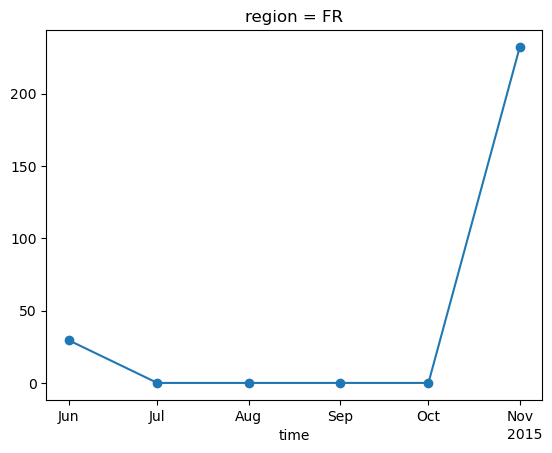

In [33]:
weighted_edd.plot(marker='o')

Now we load the population weight mask in order to aggregate edd taking into account the density of people in each pixel.

In [34]:
popw_path = "./data/nc/popweights/ANCI_POPW-coeff_C3S2LOT1_025d_v1.00.nc"
popw = shift_longitude(xr.open_dataset(popw_path))
popw

<xarray.Dataset> Size: 4MB
Dimensions:    (latitude: 721, time: 1, longitude: 1440)
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 8B 2020-05-01
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    PopCount   (time, latitude, longitude) float32 4MB ...
Attributes:
    CDI:                       Climate Data Interface version 2.1.1 (https://...
    Conventions:               CF-1.4
    history:                   Tue Oct 10 12:03:19 2023: cdo remapcon,gridc3s...
    proj4:                     +proj=longlat +datum=WGS84 +no_defs +ellps=WGS...
    created_by:                R, packages ncdf4 and raster (version 2.8-4)
    date:                      2018-11-16 09:57:12
    NCO:                       "4.6.3"
    nco_openmp_thread_number:  1
    CDO:                       Climate Data Operators version 2.1.1 (https://...

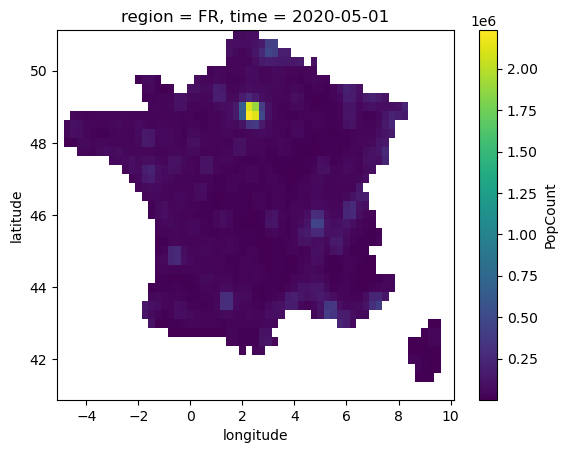

In [35]:
popw = popw.sel(latitude=lat_slice,longitude=lon_slice)
popw = xr.where(region_mask>0, popw, np.nan).compute()
popw.PopCount.plot()

We will now define our new weights that take into account both the fraction of pixel contained in the region considered and the population of that pixel, by taking the product of the two datarrays.

In [36]:
weights = (popw.isel(time=0).PopCount*region_mask)

In [47]:
popw_edd = (edd_region_monthly*weights).sum(dim=['latitude','longitude'])/weights.sum()
popw_edd = popw_edd.compute()

In [48]:
popw_edd

<xarray.DataArray (time: 6)> Size: 48B
array([ 27.00324318,   0.        ,   0.        ,   0.        ,
         0.        , 221.44964059])
Coordinates:
    region   <U4 16B 'FR'
  * time     (time) datetime64[ns] 48B 2015-06-01 2015-07-01 ... 2015-11-01

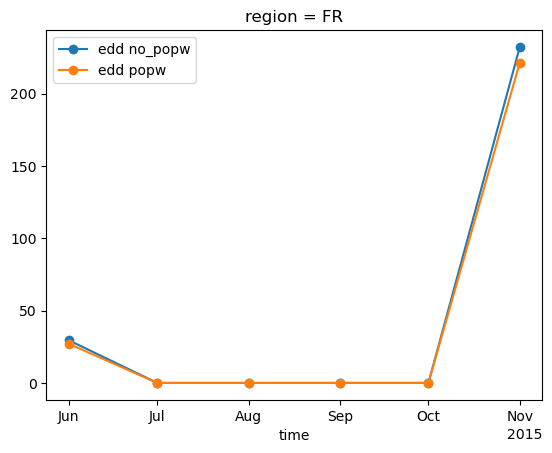

In [39]:
weighted_edd.plot(marker='o', label='edd no_popw')
popw_edd.plot(marker='o', label='edd popw')
plt.legend()

From the graph above, we can see that the values in the winter season are lower when weighted according to population. This is because the points where the EDD values (which are the temperature differences) are highest are located in the mountains, but these points are also the least populated areas.

Now we are going to open IEA load data and compute pearson corelation coefficient with our edd values. To do this we will define a function to read a csv file with monthly data of electricity consumption aggregated by countries:

In [49]:
# Function to read and filter IEA data
def read_and_filter_iea(fname):
    balance = "Final Consumption (Calculated)"
    product = "Electricity"
        
    # Read the data 
    data = pd.read_csv(fname, skiprows=8, delimiter=';',decimal=',')  # Skip metadata lines

    # Clean column names
    data.columns = [col.strip().replace(" ", "_") for col in data.columns]
    
    # Filter data based on user input
    filtered_data = data[(data['Balance'] == balance) & (data['Product'] == product)]
    
    # Rename columns
    filtered_data = filtered_data.rename(columns={"Time": "Date", "Value": "Load"})
    
    # Convert Date to datetime format
    filtered_data["Date"] = pd.to_datetime(filtered_data["Date"], format="%d/%m/%Y")
    
    # Drop 'Unit' column if it exists
    filtered_data = filtered_data.drop(columns=["Unit", "Balance", "Product"], errors="ignore")
    # Sort data in chronological order
    filtered_data = filtered_data.sort_values(by="Date").reset_index(drop=True)

    return filtered_data


In [50]:
iea_path = "./data/csv/IEA_Monthly_Electricity_Statistics_Dec2024.csv"
iea_load = read_and_filter_iea(iea_path)
iea_load

,Country,Date,Load,Unnamed:_6,Unnamed:_7,Unnamed:_8,Unnamed:_9
0,IEA Total,2010-01-01,877213.62,NaN,NaN,NaN,NaN
1,Korea,2010-01-01,42623.71,NaN,NaN,NaN,NaN
2,Japan,2010-01-01,92092.60,NaN,NaN,NaN,NaN
3,Italy,2010-01-01,26741.14,NaN,NaN,NaN,NaN
4,Ireland,2010-01-01,2521.84,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
7375,Norway,2024-12-01,13145.09,NaN,NaN,NaN,NaN
7376,New Zealand,2024-12-01,3215.39,NaN,NaN,NaN,NaN
7377,Netherlands,2024-12-01,10188.76,NaN,NaN,NaN,NaN
7378,Sweden,2024-12-01,12426.08,NaN,NaN,NaN,NaN


Now we select data for the selected country and year from the dataframe, then we plot the resulting timeseries along with our edd previously computed:

In [56]:
df = iea_load[(iea_load['Country']=='France') & (iea_load['Date'].dt.year==year) & ((iea_load['Date'].dt.month==6) | (iea_load['Date'].dt.month==11))]
df = df.set_index('Date')

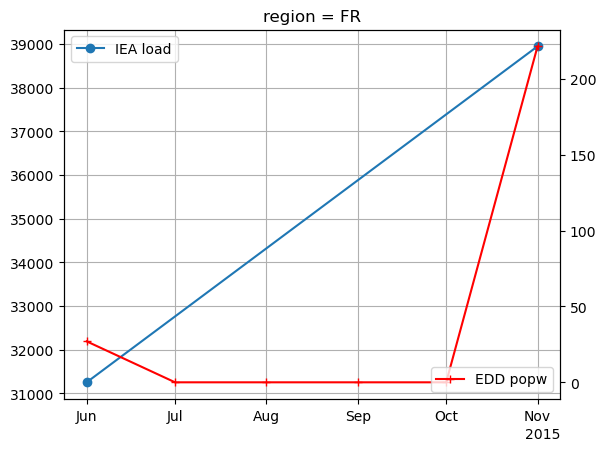

In [58]:
fig, ax1 = plt.subplots()
#plt.title(f"IEA load for region {selected_region} and year {year}")
ax1.plot(df['Load'], marker='o', label='IEA load')
plt.grid()
plt.legend()
ax2 = ax1.twinx()
popw_edd.plot(ax=ax2, marker='+', label='EDD popw', color='red')
plt.legend(loc='lower right')

We can already see that there is a very good correlation between the two. Let's quantify this correlation by computing the Pearson correlation coefficient between our edd values and IEA load data, both for edd computed with population weight mask and without:

In [66]:
print(popw_edd)
popw_edd_nonzero = popw_edd.where(popw_edd != 0, drop=True)
weighted_edd_nonzero = weighted_edd.where(popw_edd != 0, drop=True)
r_nopopw = np.corrcoef(weighted_edd_nonzero.values, df['Load'].values)[0, 1]
r_popw = np.corrcoef(popw_edd_nonzero.values, df['Load'].values)[0, 1]

<xarray.DataArray (time: 6)> Size: 48B
array([ 27.00324318,   0.        ,   0.        ,   0.        ,
         0.        , 221.44964059])
Coordinates:
    region   <U4 16B 'FR'
  * time     (time) datetime64[ns] 48B 2015-06-01 2015-07-01 ... 2015-11-01


In [67]:
r_nopopw.item(),r_popw.item()

(1.0, 0.9999999999999998)

The Pearson correlation coefficient values are very high, and in fact EDD is an excellent indicator of electricity demand in France. Using a population weighting mask, we can obtain a slight improvement.

## Take home messages 📌

* Energy degree days (EDD) is an indicator of energy demand calculated using only temperature data, useful for countries where electricity load data is unavailable or of inadequate quality.
* Population weighting can be used for more accurate aggregation.
* EDD values are highly correlated with electricity demand for France.